# Naive Bayes without dropping actual departure time and TAXI_OUT

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [83]:
data = pd.read_csv('../M1_final.csv')

In [84]:
data.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,32,58,W,24,35,29.91,Fair / Windy,9,17,13


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28820 entries, 0 to 28819
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28820 non-null  int64  
 1   DAY_OF_MONTH       28820 non-null  int64  
 2   DAY_OF_WEEK        28820 non-null  int64  
 3   OP_UNIQUE_CARRIER  28820 non-null  object 
 4   TAIL_NUM           28820 non-null  object 
 5   DEST               28820 non-null  object 
 6   DEP_DELAY          28820 non-null  int64  
 7   CRS_ELAPSED_TIME   28820 non-null  int64  
 8   DISTANCE           28820 non-null  int64  
 9   CRS_DEP_M          28820 non-null  int64  
 10  DEP_TIME_M         28820 non-null  int64  
 11  CRS_ARR_M          28820 non-null  int64  
 12  Temperature        28820 non-null  int64  
 13  Dew Point          28820 non-null  object 
 14  Humidity           28820 non-null  int64  
 15  Wind               28818 non-null  object 
 16  Wind Speed         288

In [86]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [87]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)

### Temporal lag feature

In [88]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified train test split

In [89]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind direction transformer

In [90]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew Point Transformer

In [91]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [92]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

## Hyperparameter tuning with Optuna

In [93]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB

### Naive Bayes Variants Being Explored:

1. **GaussianNB** - Assumes features follow normal distribution (best for continuous features)
2. **MultinomialNB** - For discrete count data (requires non-negative features)
3. **ComplementNB** - Improved MultinomialNB, better for imbalanced datasets
4. **BernoulliNB** - For binary/boolean features

Optuna will automatically explore all variants and their hyperparameters to find the best combination!

In [94]:
def objective(trial):
    # Let Optuna choose which Naive Bayes variant to use
    nb_type = trial.suggest_categorical('nb_type', ['GaussianNB', 'MultinomialNB', 'ComplementNB', 'BernoulliNB'])
    
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import MinMaxScaler
    
    # Optimize class priors - important for imbalanced datasets!
    # If use_custom_priors=True, optimize the prior for class 1 (delayed)
    use_custom_priors = trial.suggest_categorical('use_custom_priors', [True, False])
    
    if use_custom_priors:
        # Suggest prior probability for class 1 (delayed flights)
        # The prior for class 0 will be (1 - class_1_prior)
        class_1_prior = trial.suggest_float('class_1_prior', 0.2, 0.8)
        priors = [1 - class_1_prior, class_1_prior]
    else:
        priors = None  # Use empirical priors from training data
    
    if nb_type == 'GaussianNB':
        # GaussianNB hyperparameters (works with any features)
        var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-5, log=True)
        nb_model = GaussianNB(var_smoothing=var_smoothing, priors=priors)
        
        # GaussianNB doesn't need scaling
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Train NaiveBayes', nb_model)
        ])
        
    elif nb_type == 'MultinomialNB':
        # MultinomialNB hyperparameters (requires non-negative features)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        
        # MultinomialNB uses class_prior instead of priors
        nb_model = MultinomialNB(
            alpha=alpha, 
            fit_prior=fit_prior,
            class_prior=priors if not fit_prior else None
        )
        
        # Add MinMaxScaler to ensure non-negative features
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Scaler', MinMaxScaler()),  # Scale to [0, 1]
            ('Train NaiveBayes', nb_model)
        ])
        
    elif nb_type == 'ComplementNB':
        # ComplementNB hyperparameters (good for imbalanced data, requires non-negative)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        norm = trial.suggest_categorical('norm', [True, False])
        
        # ComplementNB uses class_prior instead of priors
        nb_model = ComplementNB(
            alpha=alpha, 
            fit_prior=fit_prior, 
            norm=norm,
            class_prior=priors if not fit_prior else None
        )
        
        # Add MinMaxScaler to ensure non-negative features
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Scaler', MinMaxScaler()),  # Scale to [0, 1]
            ('Train NaiveBayes', nb_model)
        ])
        
    else:  # BernoulliNB
        # BernoulliNB hyperparameters (for binary features)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        binarize = trial.suggest_float('binarize', 0.0, 1.0)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        
        # BernoulliNB uses class_prior instead of priors
        nb_model = BernoulliNB(
            alpha=alpha, 
            binarize=binarize, 
            fit_prior=fit_prior,
            class_prior=priors if not fit_prior else None
        )
        
        # BernoulliNB works with any features (it binarizes internally)
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Train NaiveBayes', nb_model)
        ])
    
    # Perform cross-validation
    # Using accuracy as the metric
    try:
        cv_scores = cross_val_score(
            trial_pipe, 
            x_train, 
            y_train, 
            cv=5, 
            scoring='accuracy',
            n_jobs=-1
        )
        return cv_scores.mean()
    except Exception as e:
        # If any error occurs, return a very low score
        print(f"Error with {nb_type}: {str(e)}")
        return 0.0

In [95]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='NaiveBayes_Hyperparameter_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization with more trials to explore all variants
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n" + "="*50)
print("Optimization completed!")
print("="*50)

[I 2025-10-29 02:53:15,069] A new study created in memory with name: NaiveBayes_Hyperparameter_Tuning
Best trial: 0. Best value: 0.871852:   1%|          | 1/100 [00:00<00:21,  4.68it/s]

[I 2025-10-29 02:53:15,282] Trial 0 finished with value: 0.8718519474184425 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.23485016730091968, 'alpha': 3.9676050770529883, 'fit_prior': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   2%|▏         | 2/100 [00:00<00:21,  4.66it/s]

[I 2025-10-29 02:53:15,497] Trial 1 finished with value: 0.8701663739257206 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.08179499475211674, 'fit_prior': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   3%|▎         | 3/100 [00:00<00:21,  4.62it/s]

[I 2025-10-29 02:53:15,715] Trial 2 finished with value: 0.7866863015053581 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.267398652378039, 'fit_prior': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   4%|▍         | 4/100 [00:00<00:20,  4.70it/s]

[I 2025-10-29 02:53:15,922] Trial 3 finished with value: 0.7860914199563929 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 7.886714129990489, 'fit_prior': True, 'norm': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   5%|▌         | 5/100 [00:01<00:20,  4.74it/s]

[I 2025-10-29 02:53:16,131] Trial 4 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.5975133706123892, 'alpha': 0.08612579192594885, 'fit_prior': False, 'norm': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   6%|▌         | 6/100 [00:01<00:20,  4.69it/s]

[I 2025-10-29 02:53:16,348] Trial 5 finished with value: 0.8486520216327265 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3175897174514871, 'alpha': 0.013667272915456224, 'fit_prior': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   7%|▋         | 7/100 [00:01<00:20,  4.46it/s]

[I 2025-10-29 02:53:16,595] Trial 6 finished with value: 0.8702159525077733 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.6813181884524239, 'alpha': 0.01673601016782578, 'fit_prior': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   8%|▊         | 8/100 [00:01<00:20,  4.51it/s]

[I 2025-10-29 02:53:16,811] Trial 7 finished with value: 0.8563856537891368 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 0.016677615430197915, 'fit_prior': True, 'norm': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:   9%|▉         | 9/100 [00:01<00:19,  4.56it/s]

[I 2025-10-29 02:53:17,025] Trial 8 finished with value: 0.7836618359802889 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.7323276455457961, 'var_smoothing': 2.0207122587167317e-09}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  10%|█         | 10/100 [00:02<00:19,  4.63it/s]

[I 2025-10-29 02:53:17,234] Trial 9 finished with value: 0.786537639481999 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.5136396976291965, 'alpha': 0.19170041589170655, 'fit_prior': False, 'norm': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  11%|█         | 11/100 [00:02<00:19,  4.60it/s]

[I 2025-10-29 02:53:17,455] Trial 10 finished with value: 0.8231223816887313 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.20452839158977593, 'alpha': 1.335929285535435, 'binarize': 0.33161751444757637, 'fit_prior': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  12%|█▏        | 12/100 [00:02<00:19,  4.63it/s]

[I 2025-10-29 02:53:17,667] Trial 11 finished with value: 0.8701663739257206 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.7681771258340897, 'alpha': 0.8533716477932941, 'fit_prior': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  13%|█▎        | 13/100 [00:02<00:18,  4.60it/s]

[I 2025-10-29 02:53:17,888] Trial 12 finished with value: 0.8701663739257206 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.37534307930119193, 'alpha': 9.579236335397281, 'fit_prior': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  14%|█▍        | 14/100 [00:03<00:18,  4.59it/s]

[I 2025-10-29 02:53:18,105] Trial 13 finished with value: 0.7994756220207542 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.6542125502254114, 'var_smoothing': 1.2119094883958563e-12}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  15%|█▌        | 15/100 [00:03<00:18,  4.55it/s]

[I 2025-10-29 02:53:18,330] Trial 14 finished with value: 0.7536358179759528 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.4540236223098326, 'alpha': 0.36797592777483795, 'binarize': 0.9713671837659094, 'fit_prior': True}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 0. Best value: 0.871852:  16%|█▌        | 16/100 [00:03<00:18,  4.59it/s]

[I 2025-10-29 02:53:18,544] Trial 15 finished with value: 0.8703152694046086 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2470774309800684, 'alpha': 0.03914902714255588, 'fit_prior': False}. Best is trial 0 with value: 0.8718519474184425.


Best trial: 16. Best value: 0.87552:  17%|█▋        | 17/100 [00:03<00:21,  3.83it/s]

[I 2025-10-29 02:53:18,907] Trial 16 finished with value: 0.8755203078664071 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.21362235435359408, 'alpha': 0.05217514636169648, 'fit_prior': False}. Best is trial 16 with value: 0.8755203078664071.


Best trial: 16. Best value: 0.87552:  18%|█▊        | 18/100 [00:04<00:20,  4.03it/s]

[I 2025-10-29 02:53:19,124] Trial 17 finished with value: 0.8500401359202664 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3111558436304508, 'alpha': 3.7517445664244677, 'fit_prior': False}. Best is trial 16 with value: 0.8755203078664071.


Best trial: 16. Best value: 0.87552:  19%|█▉        | 19/100 [00:04<00:19,  4.19it/s]

[I 2025-10-29 02:53:19,341] Trial 18 finished with value: 0.8376962608410912 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 7.500526724088232e-06}. Best is trial 16 with value: 0.8755203078664071.


Best trial: 16. Best value: 0.87552:  20%|██        | 20/100 [00:04<00:18,  4.33it/s]

[I 2025-10-29 02:53:19,554] Trial 19 finished with value: 0.8000703192627228 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.41708243140944, 'alpha': 0.4508828475746824, 'binarize': 0.010989189243771236, 'fit_prior': False}. Best is trial 16 with value: 0.8755203078664071.


Best trial: 16. Best value: 0.87552:  21%|██        | 21/100 [00:04<00:18,  4.39it/s]

[I 2025-10-29 02:53:19,776] Trial 20 finished with value: 0.8586163950903074 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2849505449914107, 'alpha': 0.06882276904005022, 'fit_prior': False}. Best is trial 16 with value: 0.8755203078664071.


Best trial: 21. Best value: 0.87676:  22%|██▏       | 22/100 [00:04<00:17,  4.44it/s]

[I 2025-10-29 02:53:19,995] Trial 21 finished with value: 0.876759674120656 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20129349384957, 'alpha': 0.03244191070587435, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  23%|██▎       | 23/100 [00:05<00:17,  4.46it/s]

[I 2025-10-29 02:53:20,215] Trial 22 finished with value: 0.8763630823256348 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2079075286285541, 'alpha': 0.036765169266719896, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  24%|██▍       | 24/100 [00:05<00:16,  4.55it/s]

[I 2025-10-29 02:53:20,425] Trial 23 finished with value: 0.8766605169565509 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20287326731006664, 'alpha': 0.03613721939196292, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  25%|██▌       | 25/100 [00:05<00:16,  4.59it/s]

[I 2025-10-29 02:53:20,639] Trial 24 finished with value: 0.841265562422015 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.35627381895397087, 'alpha': 0.02946578043093706, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  26%|██▌       | 26/100 [00:05<00:15,  4.64it/s]

[I 2025-10-29 02:53:20,849] Trial 25 finished with value: 0.8615411751045482 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.27656583758529657, 'alpha': 0.15433162405210815, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  27%|██▋       | 27/100 [00:06<00:15,  4.62it/s]

[I 2025-10-29 02:53:21,068] Trial 26 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.026627855821028026, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  28%|██▊       | 28/100 [00:06<00:15,  4.59it/s]

[I 2025-10-29 02:53:21,288] Trial 27 finished with value: 0.8038878700807695 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.20195645946605864, 'var_smoothing': 5.304034914645736e-06}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  30%|███       | 30/100 [00:06<00:12,  5.45it/s]

[I 2025-10-29 02:53:21,499] Trial 28 finished with value: 0.42073800207529677 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.5274355235450485, 'alpha': 0.010167880842717032, 'binarize': 0.9962253844052456, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.
[I 2025-10-29 02:53:21,608] Trial 29 finished with value: 0.8431988445180034 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3392451922637354, 'alpha': 0.12472056314762536, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  31%|███       | 31/100 [00:06<00:13,  5.25it/s]

[I 2025-10-29 02:53:21,815] Trial 30 finished with value: 0.8673905631131664 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.257378724343956, 'alpha': 0.02608524477278542, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  32%|███▏      | 32/100 [00:06<00:13,  5.07it/s]

[I 2025-10-29 02:53:22,027] Trial 31 finished with value: 0.8763135160307154 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20749903463006866, 'alpha': 0.04829017144919897, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  33%|███▎      | 33/100 [00:07<00:13,  4.95it/s]

[I 2025-10-29 02:53:22,240] Trial 32 finished with value: 0.8642180253471269 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.26777600991693884, 'alpha': 0.04678763046358709, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  34%|███▍      | 34/100 [00:07<00:13,  4.86it/s]

[I 2025-10-29 02:53:22,454] Trial 33 finished with value: 0.8764126486205542 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20504021861432617, 'alpha': 0.02167124356389002, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  35%|███▌      | 35/100 [00:07<00:13,  4.81it/s]

[I 2025-10-29 02:53:22,668] Trial 34 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.02229560906772724, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  36%|███▌      | 36/100 [00:07<00:13,  4.78it/s]

[I 2025-10-29 02:53:22,879] Trial 35 finished with value: 0.857178702220715 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.28965384663376126, 'alpha': 0.01058002512773257, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  37%|███▋      | 37/100 [00:08<00:13,  4.77it/s]

[I 2025-10-29 02:53:23,090] Trial 36 finished with value: 0.856484810953242 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 0.07939456870342114, 'fit_prior': False, 'norm': True}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  38%|███▊      | 38/100 [00:08<00:13,  4.76it/s]

[I 2025-10-29 02:53:23,302] Trial 37 finished with value: 0.8385885770209723 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.37312620090395954, 'alpha': 0.03330989790754773, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  39%|███▉      | 39/100 [00:08<00:12,  4.74it/s]

[I 2025-10-29 02:53:23,514] Trial 38 finished with value: 0.8720006831646003 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.23745228600390345, 'alpha': 0.106546640886642, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  40%|████      | 40/100 [00:08<00:12,  4.75it/s]

[I 2025-10-29 02:53:23,724] Trial 39 finished with value: 0.786537639481999 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.19800952017728835, 'fit_prior': False}. Best is trial 21 with value: 0.876759674120656.


Best trial: 21. Best value: 0.87676:  41%|████      | 41/100 [00:08<00:12,  4.74it/s]

[I 2025-10-29 02:53:23,936] Trial 40 finished with value: 0.856484810953242 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.24709392538776725, 'alpha': 0.06212786060544104, 'fit_prior': False, 'norm': True}. Best is trial 21 with value: 0.876759674120656.


Best trial: 41. Best value: 0.876809:  42%|████▏     | 42/100 [00:09<00:12,  4.73it/s]

[I 2025-10-29 02:53:24,149] Trial 41 finished with value: 0.8768092404155755 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20147154860069758, 'alpha': 0.04169133567455285, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  43%|████▎     | 43/100 [00:09<00:12,  4.73it/s]

[I 2025-10-29 02:53:24,360] Trial 42 finished with value: 0.8766605415308172 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20059025971844055, 'alpha': 0.020158072835882567, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  44%|████▍     | 44/100 [00:09<00:11,  4.70it/s]

[I 2025-10-29 02:53:24,575] Trial 43 finished with value: 0.8714057893285021 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2406211539979305, 'alpha': 0.01826711208250501, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  45%|████▌     | 45/100 [00:09<00:11,  4.70it/s]

[I 2025-10-29 02:53:24,788] Trial 44 finished with value: 0.8470657036011744 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.32320983627208066, 'alpha': 0.014866660822870536, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  46%|████▌     | 46/100 [00:09<00:11,  4.71it/s]

[I 2025-10-29 02:53:25,000] Trial 45 finished with value: 0.8702159525077733 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.28825274375307514, 'alpha': 0.019408746149442935, 'fit_prior': True}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  47%|████▋     | 47/100 [00:10<00:11,  4.71it/s]

[I 2025-10-29 02:53:25,212] Trial 46 finished with value: 0.8099850404154525 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.5612776129264812, 'var_smoothing': 1.9380244497921887e-11}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  48%|████▊     | 48/100 [00:10<00:11,  4.70it/s]

[I 2025-10-29 02:53:25,426] Trial 47 finished with value: 0.786537651769132 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.23703994169889894, 'alpha': 0.014214430399005855, 'fit_prior': False, 'norm': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  49%|████▉     | 49/100 [00:10<00:10,  4.65it/s]

[I 2025-10-29 02:53:25,646] Trial 48 finished with value: 0.7468931308168056 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.31665990005936506, 'alpha': 0.022539419511759595, 'binarize': 0.6282831924278418, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  50%|█████     | 50/100 [00:10<00:11,  4.43it/s]

[I 2025-10-29 02:53:25,897] Trial 49 finished with value: 0.8702159525077733 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2003248474098386, 'alpha': 0.03891897901982829, 'fit_prior': True}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  51%|█████     | 51/100 [00:11<00:10,  4.50it/s]

[I 2025-10-29 02:53:26,112] Trial 50 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.09580626702852738, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  52%|█████▏    | 52/100 [00:11<00:10,  4.58it/s]

[I 2025-10-29 02:53:26,321] Trial 51 finished with value: 0.8736365674910719 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.22555077441889332, 'alpha': 0.03532436258968461, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  53%|█████▎    | 53/100 [00:11<00:10,  4.62it/s]

[I 2025-10-29 02:53:26,533] Trial 52 finished with value: 0.876759674120656 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20195827559268054, 'alpha': 0.028353848505457302, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  55%|█████▌    | 55/100 [00:11<00:08,  5.39it/s]

[I 2025-10-29 02:53:26,742] Trial 53 finished with value: 0.8635240234954559 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2686546983348195, 'alpha': 0.05437446995297542, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.
[I 2025-10-29 02:53:26,861] Trial 54 finished with value: 0.8739340021219879 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.22442264050434943, 'alpha': 0.01196114978337653, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  56%|█████▌    | 56/100 [00:11<00:08,  5.21it/s]

[I 2025-10-29 02:53:27,068] Trial 55 finished with value: 0.8702159525077733 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2539905068645907, 'alpha': 0.01873273483706244, 'fit_prior': True}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  57%|█████▋    | 57/100 [00:12<00:08,  5.06it/s]

[I 2025-10-29 02:53:27,279] Trial 56 finished with value: 0.7799439583859376 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.652300361634277, 'var_smoothing': 2.5373554969866667e-08}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  59%|█████▉    | 59/100 [00:12<00:07,  5.71it/s]

[I 2025-10-29 02:53:27,491] Trial 57 finished with value: 0.836308490593278 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.4194976162174572, 'alpha': 0.026960667636471494, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.
[I 2025-10-29 02:53:27,604] Trial 58 finished with value: 0.8001694641396948 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.22989590087290002, 'alpha': 0.6433253740869411, 'binarize': 0.027015830584578238, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  60%|██████    | 60/100 [00:12<00:07,  5.43it/s]

[I 2025-10-29 02:53:27,808] Trial 59 finished with value: 0.85370853322963 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3017591858545785, 'alpha': 0.07328363029332029, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  61%|██████    | 61/100 [00:12<00:07,  5.19it/s]

[I 2025-10-29 02:53:28,021] Trial 60 finished with value: 0.17499643365961814 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.789112437887829, 'alpha': 0.2629649965247842, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  62%|██████▏   | 62/100 [00:13<00:07,  5.02it/s]

[I 2025-10-29 02:53:28,236] Trial 61 finished with value: 0.8766109260873651 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2033687290296813, 'alpha': 0.041595080144469096, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  63%|██████▎   | 63/100 [00:13<00:07,  4.93it/s]

[I 2025-10-29 02:53:28,447] Trial 62 finished with value: 0.8767101078257366 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20010296587552606, 'alpha': 0.04674685427094961, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  64%|██████▍   | 64/100 [00:13<00:07,  4.85it/s]

[I 2025-10-29 02:53:28,660] Trial 63 finished with value: 0.8728929747702153 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2281446498628763, 'alpha': 0.04215262564327701, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  65%|██████▌   | 65/100 [00:13<00:07,  4.75it/s]

[I 2025-10-29 02:53:28,879] Trial 64 finished with value: 0.8766605415308172 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20053008540238026, 'alpha': 0.06010718319968852, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  66%|██████▌   | 66/100 [00:14<00:07,  4.70it/s]

[I 2025-10-29 02:53:29,099] Trial 65 finished with value: 0.8651102800913426 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.26570824501616735, 'alpha': 0.059585664652039835, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  67%|██████▋   | 67/100 [00:14<00:07,  4.70it/s]

[I 2025-10-29 02:53:29,311] Trial 66 finished with value: 0.8564352323711895 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.24887447766648513, 'alpha': 0.029469231394044844, 'fit_prior': True, 'norm': True}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  68%|██████▊   | 68/100 [00:14<00:06,  4.72it/s]

[I 2025-10-29 02:53:29,522] Trial 67 finished with value: 0.8742810399092227 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.22003917687303734, 'alpha': 2.3480343397462535, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  69%|██████▉   | 69/100 [00:14<00:06,  4.71it/s]

[I 2025-10-29 02:53:29,734] Trial 68 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.11923509238878535, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  70%|███████   | 70/100 [00:14<00:06,  4.58it/s]

[I 2025-10-29 02:53:29,967] Trial 69 finished with value: 0.8193543480170717 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.4758136426077737, 'var_smoothing': 3.6786724926697467e-09}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  71%|███████   | 71/100 [00:15<00:06,  4.65it/s]

[I 2025-10-29 02:53:30,175] Trial 70 finished with value: 0.8650607260835562 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.26604427350119453, 'alpha': 0.08628189500853488, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  72%|███████▏  | 72/100 [00:15<00:05,  4.67it/s]

[I 2025-10-29 02:53:30,386] Trial 71 finished with value: 0.8763630700385017 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20910450746257805, 'alpha': 0.04631039670630259, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  73%|███████▎  | 73/100 [00:15<00:05,  4.68it/s]

[I 2025-10-29 02:53:30,599] Trial 72 finished with value: 0.8767596618335229 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2017085520244365, 'alpha': 0.034442414912863435, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  74%|███████▍  | 74/100 [00:15<00:05,  4.71it/s]

[I 2025-10-29 02:53:30,808] Trial 73 finished with value: 0.874132291875932 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.22342728441305257, 'alpha': 0.03160419823796824, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  75%|███████▌  | 75/100 [00:15<00:05,  4.71it/s]

[I 2025-10-29 02:53:31,020] Trial 74 finished with value: 0.876660529243684 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20025443350553768, 'alpha': 0.024496933669380227, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  76%|███████▌  | 76/100 [00:16<00:05,  4.66it/s]

[I 2025-10-29 02:53:31,240] Trial 75 finished with value: 0.8691255554552105 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.25186218344623934, 'alpha': 0.02382644652805813, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  77%|███████▋  | 77/100 [00:16<00:04,  4.70it/s]

[I 2025-10-29 02:53:31,449] Trial 76 finished with value: 0.8570795327694768 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.29052442619579594, 'alpha': 0.015269760434684015, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  78%|███████▊  | 78/100 [00:16<00:04,  4.65it/s]

[I 2025-10-29 02:53:31,668] Trial 77 finished with value: 0.7643938665089 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.22763189148961033, 'alpha': 0.05573173949293092, 'binarize': 0.5977434286294642, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  79%|███████▉  | 79/100 [00:16<00:04,  4.68it/s]

[I 2025-10-29 02:53:31,879] Trial 78 finished with value: 0.8767101078257366 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20073128278646496, 'alpha': 0.02923597478919497, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  80%|████████  | 80/100 [00:17<00:04,  4.65it/s]

[I 2025-10-29 02:53:32,097] Trial 79 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.07136889402552128, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  81%|████████  | 81/100 [00:17<00:04,  4.69it/s]

[I 2025-10-29 02:53:32,307] Trial 80 finished with value: 0.8714553556234215 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2404151497732527, 'alpha': 0.012490456132410491, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  82%|████████▏ | 82/100 [00:17<00:03,  4.71it/s]

[I 2025-10-29 02:53:32,517] Trial 81 finished with value: 0.8768092404155755 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.201521787128226, 'alpha': 0.03159407856331462, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  83%|████████▎ | 83/100 [00:17<00:03,  4.70it/s]

[I 2025-10-29 02:53:32,731] Trial 82 finished with value: 0.8745289082452192 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.21752954717842007, 'alpha': 0.030150926388145986, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  84%|████████▍ | 84/100 [00:17<00:03,  4.70it/s]

[I 2025-10-29 02:53:32,944] Trial 83 finished with value: 0.8743801970733278 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2194688211345104, 'alpha': 0.035387796203937144, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  85%|████████▌ | 85/100 [00:18<00:03,  4.65it/s]

[I 2025-10-29 02:53:33,164] Trial 84 finished with value: 0.8709596435256947 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.24370821482083352, 'alpha': 0.019527130640033023, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  86%|████████▌ | 86/100 [00:18<00:03,  4.67it/s]

[I 2025-10-29 02:53:33,376] Trial 85 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.27421899645695635, 'alpha': 0.04774871168819337, 'fit_prior': False, 'norm': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  87%|████████▋ | 87/100 [00:18<00:02,  4.61it/s]

[I 2025-10-29 02:53:33,600] Trial 86 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2555207295023672, 'alpha': 6.168181912653529, 'fit_prior': True}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  88%|████████▊ | 88/100 [00:18<00:02,  4.67it/s]

[I 2025-10-29 02:53:33,807] Trial 87 finished with value: 0.8749750540480268 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2160101977981046, 'alpha': 0.016317802518902386, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  89%|████████▉ | 89/100 [00:18<00:02,  4.67it/s]

[I 2025-10-29 02:53:34,021] Trial 88 finished with value: 0.8768092404155755 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20120524163770212, 'alpha': 0.06120606009445045, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  90%|█████████ | 90/100 [00:19<00:02,  4.69it/s]

[I 2025-10-29 02:53:34,233] Trial 89 finished with value: 0.8437940946809614 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.23918604872841925, 'var_smoothing': 8.096581389210026e-08}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  91%|█████████ | 91/100 [00:19<00:01,  4.69it/s]

[I 2025-10-29 02:53:34,445] Trial 90 finished with value: 0.8745289082452192 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.21927302358201503, 'alpha': 0.026356142678625752, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  92%|█████████▏| 92/100 [00:19<00:01,  4.71it/s]

[I 2025-10-29 02:53:34,656] Trial 91 finished with value: 0.8766605415308172 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20052286081148182, 'alpha': 0.03982310519950107, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  93%|█████████▎| 93/100 [00:19<00:01,  4.71it/s]

[I 2025-10-29 02:53:34,868] Trial 92 finished with value: 0.39034667531680833 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.7068298930625696, 'alpha': 0.06495311529149875, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  94%|█████████▍| 94/100 [00:20<00:01,  4.67it/s]

[I 2025-10-29 02:53:35,086] Trial 93 finished with value: 0.8727442758854569 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.22906063358840878, 'alpha': 0.14978690095202163, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  95%|█████████▌| 95/100 [00:20<00:01,  4.69it/s]

[I 2025-10-29 02:53:35,298] Trial 94 finished with value: 0.8756194527433788 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.21225488052756114, 'alpha': 0.053268685951934173, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  96%|█████████▌| 96/100 [00:20<00:00,  4.63it/s]

[I 2025-10-29 02:53:35,519] Trial 95 finished with value: 0.8768092404155755 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20144140834520444, 'alpha': 0.03058377675903719, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  97%|█████████▋| 97/100 [00:20<00:00,  4.65it/s]

[I 2025-10-29 02:53:35,732] Trial 96 finished with value: 0.5932572391180543 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.6121909404292113, 'alpha': 0.02124755977378952, 'binarize': 0.34083547923336743, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  98%|█████████▊| 98/100 [00:20<00:00,  4.66it/s]

[I 2025-10-29 02:53:35,946] Trial 97 finished with value: 0.7865872180640515 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.031001145723968178, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809:  99%|█████████▉| 99/100 [00:21<00:00,  4.64it/s]

[I 2025-10-29 02:53:36,163] Trial 98 finished with value: 0.8720006831646003 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.23706423146038003, 'alpha': 0.034604986999095234, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.


Best trial: 41. Best value: 0.876809: 100%|██████████| 100/100 [00:21<00:00,  4.69it/s]

[I 2025-10-29 02:53:36,374] Trial 99 finished with value: 0.8609463181298492 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2776063856899279, 'alpha': 0.04322349637175571, 'fit_prior': False}. Best is trial 41 with value: 0.8768092404155755.

Optimization completed!


## Results

In [96]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print(f"\nBest Naive Bayes Variant: {study.best_params['nb_type']}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Show distribution of variants tried
print("\n" + "="*50)
print("Variant Performance Summary:")
print("="*50)
variant_scores = {}
for trial in study.trials:
    if trial.state.name == 'COMPLETE':
        nb_type = trial.params['nb_type']
        if nb_type not in variant_scores:
            variant_scores[nb_type] = []
        variant_scores[nb_type].append(trial.value)

for variant, scores in sorted(variant_scores.items()):
    avg_score = sum(scores) / len(scores)
    max_score = max(scores)
    print(f"{variant:15s} - Avg: {avg_score:.4f}, Max: {max_score:.4f}, Trials: {len(scores)}")

Best Trial:
  Value (Accuracy): 0.8768
  Number: 41

Best Naive Bayes Variant: MultinomialNB

Best Hyperparameters:
  nb_type: MultinomialNB
  use_custom_priors: True
  class_1_prior: 0.20147154860069758
  alpha: 0.04169133567455285
  fit_prior: False

Variant Performance Summary:
BernoulliNB     - Avg: 0.7128, Max: 0.8231, Trials: 8
ComplementNB    - Avg: 0.8176, Max: 0.8565, Trials: 9
GaussianNB      - Avg: 0.8097, Max: 0.8438, Trials: 8
MultinomialNB   - Avg: 0.8442, Max: 0.8768, Trials: 75


## Training the model with best hyperparameters

In [97]:
# Train final model with best parameters
from sklearn.preprocessing import MinMaxScaler

best_params = study.best_params
nb_type = best_params['nb_type']

# Get priors if custom priors were used
if best_params.get('use_custom_priors', False):
    class_1_prior = best_params['class_1_prior']
    priors = [1 - class_1_prior, class_1_prior]
else:
    priors = None

# Recreate the best model based on the variant and parameters
if nb_type == 'GaussianNB':
    best_nb_model = GaussianNB(
        var_smoothing=best_params['var_smoothing'],
        priors=priors
    )
    # GaussianNB doesn't need scaling
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Train NaiveBayes', best_nb_model)
    ])
    
elif nb_type == 'MultinomialNB':
    fit_prior = best_params['fit_prior']
    best_nb_model = MultinomialNB(
        alpha=best_params['alpha'],
        fit_prior=fit_prior,
        class_prior=priors if not fit_prior else None
    )
    # MultinomialNB needs non-negative features
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Scaler', MinMaxScaler()),
        ('Train NaiveBayes', best_nb_model)
    ])
    
elif nb_type == 'ComplementNB':
    fit_prior = best_params['fit_prior']
    best_nb_model = ComplementNB(
        alpha=best_params['alpha'],
        fit_prior=fit_prior,
        norm=best_params['norm'],
        class_prior=priors if not fit_prior else None
    )
    # ComplementNB needs non-negative features
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Scaler', MinMaxScaler()),
        ('Train NaiveBayes', best_nb_model)
    ])
    
else:  # BernoulliNB
    fit_prior = best_params['fit_prior']
    best_nb_model = BernoulliNB(
        alpha=best_params['alpha'],
        binarize=best_params['binarize'],
        fit_prior=fit_prior,
        class_prior=priors if not fit_prior else None
    )
    # BernoulliNB works without scaling
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Train NaiveBayes', best_nb_model)
    ])

# Fit the model
print(f"Training final model with best variant: {nb_type}")
print("Best parameters:", best_params)
if priors:
    print(f"Using custom priors: [Not Delayed: {priors[0]:.4f}, Delayed: {priors[1]:.4f}]")
else:
    print("Using empirical priors from training data")
final_pipe.fit(x_train, y_train)

Training final model with best variant: MultinomialNB
Best parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.20147154860069758, 'alpha': 0.04169133567455285, 'fit_prior': False}
Using custom priors: [Not Delayed: 0.7985, Delayed: 0.2015]


,steps,"[('Preprocessor', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluating on test set

In [98]:
# Make predictions on test set
y_pred = final_pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {100 * accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  87.4740
Precision: 0.6814
Recall:    0.1915
F1 Score:  0.2990


### Classification report

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      7440
           1       0.68      0.19      0.30      1206

    accuracy                           0.87      8646
   macro avg       0.78      0.59      0.62      8646
weighted avg       0.85      0.87      0.84      8646



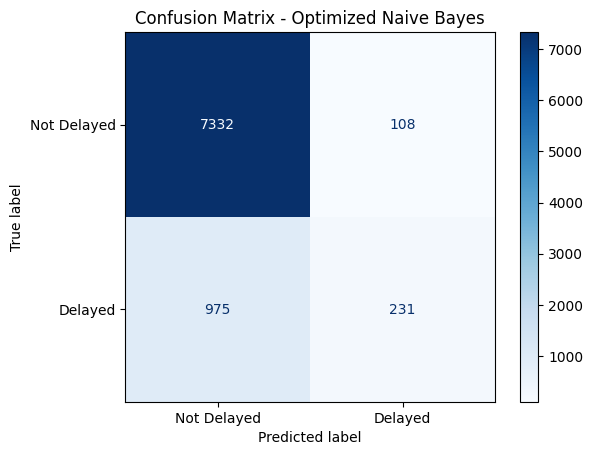

In [100]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized Naive Bayes')
plt.show()

## ROC AUC Score

ROC AUC Score: 86.3797


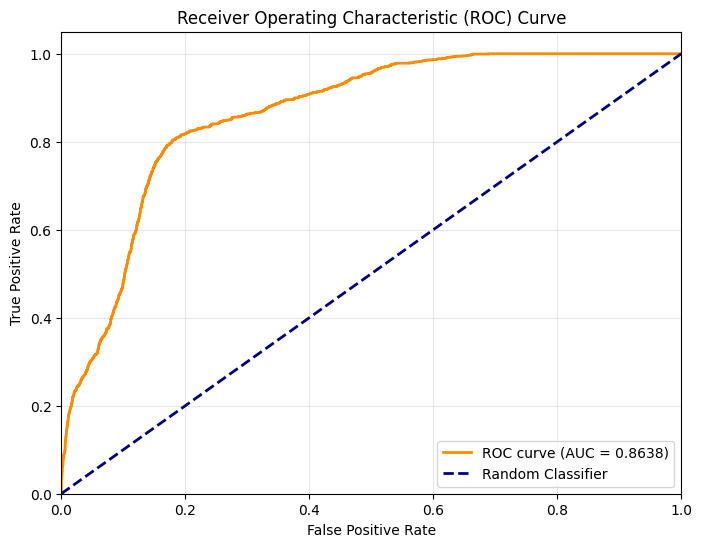

In [101]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = final_pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Specificity and Sensitivity

In [102]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9855 or 98.55%
Sensitivity (True Positive Rate): 0.1915 or 19.15%


## Save the trained model

In [103]:
# import pickle
# import os
# from datetime import datetime

# # Create the saved_models directory if it doesn't exist
# save_dir = '../saved_models/'
# os.makedirs(save_dir, exist_ok=True)

# # Create a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# nb_variant = study.best_params['nb_type']
# model_filename = os.path.join(save_dir, f'NaiveBayes_{nb_variant}_model_{timestamp}.pkl')

# # Save the entire pipeline (preprocessor + model)
# with open(model_filename, 'wb') as file:
#     pickle.dump(final_pipe, file)

# print(f"Model saved successfully as: {model_filename}")
# print(f"Best Naive Bayes variant: {nb_variant}")

# # Also save the best parameters for reference
# params_filename = os.path.join(save_dir, f'NB_{nb_variant}_BestParams_JFKFlightTakeoff_{timestamp}.pkl')
# with open(params_filename, 'wb') as file:
#     pickle.dump(study.best_params, file)

# print(f"Best parameters saved as: {params_filename}")